In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

customers = pd.read_parquet(PROC / "customer_metrics.parquet").set_index("customer_unique_id")
print(f"\ncustomers loaded: {len(customers):,}")
display(customers[["recency", "frequency", "monetary", "aov", "n_categories"]].describe().round(2))

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104



customers loaded: 93,104


,recency,frequency,monetary,aov,n_categories
count,"93,104.00","93,104.00","93,104.00","93,104.00","93,104.00"
mean,238.24,1.03,141.57,137.47,1.03
std,150.95,0.21,215.76,209.92,0.17
min,2.00,1.00,0.85,0.85,1.00
25%,116.00,1.00,47.65,46.00,1.00
50%,220.00,1.00,89.70,86.99,1.00
75%,347.00,1.00,154.17,149.90,1.00
max,603.00,15.00,"13,440.00","13,440.00",5.00


In [2]:
customers["r_score"] = pd.qcut(customers.recency, 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["m_score"] = pd.qcut(customers.monetary, 5, labels=[1, 2, 3, 4, 5]).astype(int)

r_bands = customers.groupby("r_score").recency.agg(["min", "max", "count"])
r_bands.columns = ["recency_days_min", "recency_days_max", "customers"]
print("R SCORE BANDS (days since last order)")
display(r_bands.sort_index(ascending=False))

m_bands = customers.groupby("m_score").monetary.agg(["min", "max", "count"]).round(2)
m_bands.columns = ["spend_min", "spend_max", "customers"]
print("M SCORE BANDS (lifetime spend, R$)")
display(m_bands.sort_index(ascending=False))

R SCORE BANDS (days since last order)


,recency_days_min,recency_days_max,customers
r_score,,,
5,2,93,18655
4,94,178,18664
3,179,269,18650
2,270,382,18615
1,383,603,18520


M SCORE BANDS (lifetime spend, R$)


,spend_min,spend_max,customers
m_score,,,
5,179.91,"13,440.00",18443
4,109.95,179.90,18581
3,69.94,109.90,17406
2,39.90,69.90,19381
1,0.85,39.90,19293


In [3]:
print("ATTEMPTING QUINTILE SCORING ON FREQUENCY")
print(customers.frequency.value_counts().sort_index().head(6).to_string())
print(f"\nshare of customers with frequency == 1: {(customers.frequency == 1).mean()*100:.2f}%")

try:
    test = pd.qcut(customers.frequency, 5, duplicates="drop")
    print(f"\nqcut asked for 5 bins and returned {len(test.cat.categories)}:")
    print(f"  {test.cat.categories.tolist()}")
except Exception as exc:
    print(f"\nqcut failed: {exc}")

print("\n=> A single bin. Every quintile boundary lands on the value 1, so quintile scoring")
print("   cannot distinguish customers at all. It is not a tuning problem; frequency has")
print("   almost no variance to cut.")

ATTEMPTING QUINTILE SCORING ON FREQUENCY
frequency
1    90315
2     2562
3      180
4       28
5        9
6        5

share of customers with frequency == 1: 97.00%

qcut asked for 5 bins and returned 1:
  [Interval(0.999, 15.0, closed='right')]

=> A single bin. Every quintile boundary lands on the value 1, so quintile scoring
   cannot distinguish customers at all. It is not a tuning problem; frequency has
   almost no variance to cut.


In [4]:
customers["f_score"] = np.where(customers.frequency >= 3, 5,
                        np.where(customers.frequency == 2, 3, 1))

f_bands = customers.groupby("f_score").agg(
    customers=("frequency", "size"),
    orders_min=("frequency", "min"), orders_max=("frequency", "max"),
    revenue=("monetary", "sum"))
f_bands["pct_of_customers"] = (f_bands.customers / len(customers) * 100).round(3)
display(f_bands)

print("F SCORE RULE")
print("  frequency >= 3 orders -> F = 5   (the genuinely repeat customers)")
print("  frequency == 2 orders -> F = 3")
print("  frequency == 1 order  -> F = 1   (97% of the base)")
print("\nThe gap between 5 and 3 is deliberate: 3+ orders in 20 months is qualitatively")
print("different behaviour here, and a linear 1-2-3 scale would understate it.")

,customers,orders_min,orders_max,revenue,pct_of_customers
f_score,,,,,
1,90315,1,1,"12,455,672.09",97.00
3,2562,2,2,"628,326.08",2.75
5,227,3,15,"97,028.96",0.24


F SCORE RULE
  frequency >= 3 orders -> F = 5   (the genuinely repeat customers)
  frequency == 2 orders -> F = 3
  frequency == 1 order  -> F = 1   (97% of the base)

The gap between 5 and 3 is deliberate: 3+ orders in 20 months is qualitatively
different behaviour here, and a linear 1-2-3 scale would understate it.


In [5]:
def assign_segment(row):
    R, F, M = row.r_score, row.f_score, row.m_score
    if F >= 5 and R >= 4 and M >= 4:
        return "Champions"
    if F >= 5 and R >= 3:
        return "Loyal"
    if F >= 5:
        return "At Risk"
    if R >= 4 and M >= 4:
        return "Potential Loyalists"
    if R >= 4:
        return "New Customers"
    if R == 3:
        return "Needs Attention"
    if M >= 4:
        return "At Risk"
    return "Lost"

customers["rfm_cell"] = (customers.r_score.astype(str) + "-"
                         + customers.f_score.astype(str) + "-"
                         + customers.m_score.astype(str))
customers["rfm_segment"] = customers.apply(assign_segment, axis=1)
customers["rfm_sum"] = customers.r_score + customers.f_score + customers.m_score

seg = customers.groupby("rfm_segment").agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    avg_recency=("recency", "mean"), avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"), avg_aov=("aov", "mean"),
    avg_review=("avg_review", "mean"), repeat_rate=("is_repeat", lambda s: s.mean()*100))
seg["pct_of_customers"] = seg.customers / seg.customers.sum() * 100
seg["pct_of_revenue"] = seg.revenue / seg.revenue.sum() * 100
seg = seg.sort_values("revenue", ascending=False)
display(seg.round(2))
print(f"total customers assigned: {seg.customers.sum():,} of {len(customers):,}")

,customers,revenue,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_review,repeat_rate,pct_of_customers,pct_of_revenue
rfm_segment,,,,,,,,,,
Potential Loyalists,15219,"4,106,585.37",92.91,1.05,269.83,261.67,4.16,5.35,16.35,31.16
At Risk,14339,"4,008,190.71",392.88,1.06,279.53,271.26,4.14,5.11,15.40,30.41
Needs Attention,18614,"2,484,431.64",221.21,1.03,133.47,129.76,4.00,3.04,19.99,18.85
Lost,22796,"1,280,730.79",394.58,1.01,56.18,55.77,4.20,1.13,24.48,9.72
New Customers,21980,"1,228,945.64",91.11,1.01,55.91,55.47,4.24,1.20,23.61,9.32
Champions,113,"55,629.97",93.46,3.56,492.30,140.73,4.45,100.00,0.12,0.42
Loyal,43,"16,513.01",187.77,3.42,384.02,111.17,4.24,100.00,0.05,0.13


total customers assigned: 93,104 of 93,104


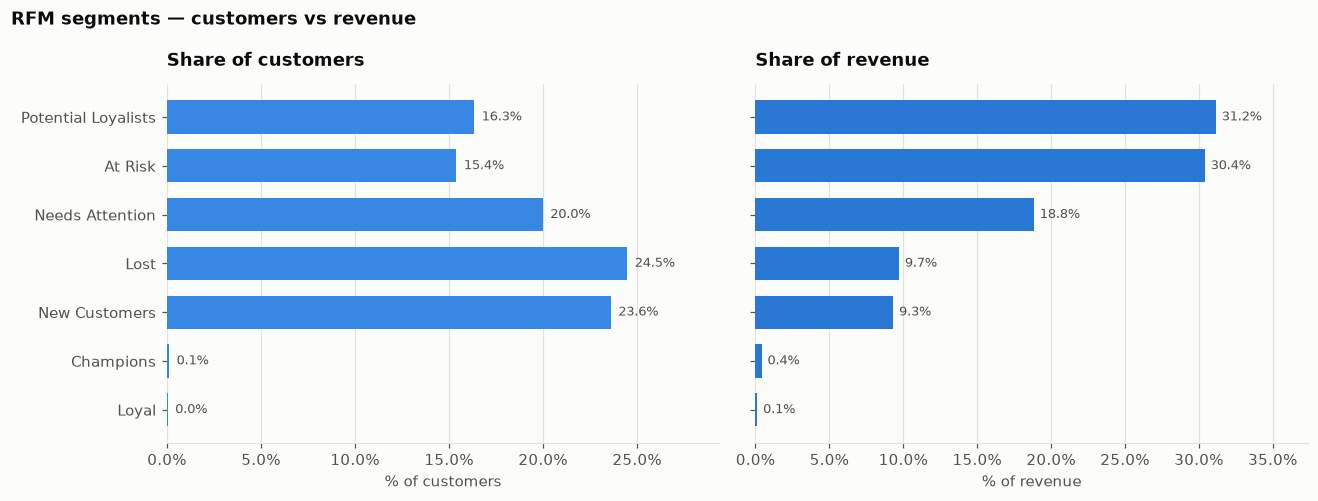

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
s = seg.sort_values("pct_of_revenue")

ax = axes[0]
ax.barh(s.index, s.pct_of_customers, color=BLUE_RAMP[3], height=0.68)
for i, v in enumerate(s.pct_of_customers):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8.5, color=INK_2)
ax.set_title("Share of customers"); ax.set_xlabel("% of customers")
ax.set_xlim(0, s.pct_of_customers.max()*1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))

ax = axes[1]
ax.barh(s.index, s.pct_of_revenue, color=BLUE, height=0.68)
for i, v in enumerate(s.pct_of_revenue):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8.5, color=INK_2)
ax.set_title("Share of revenue"); ax.set_xlabel("% of revenue")
ax.set_xlim(0, s.pct_of_revenue.max()*1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_yticklabels([])
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))

fig.suptitle("RFM segments — customers vs revenue", x=0.005, ha="left",
             fontsize=12, fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

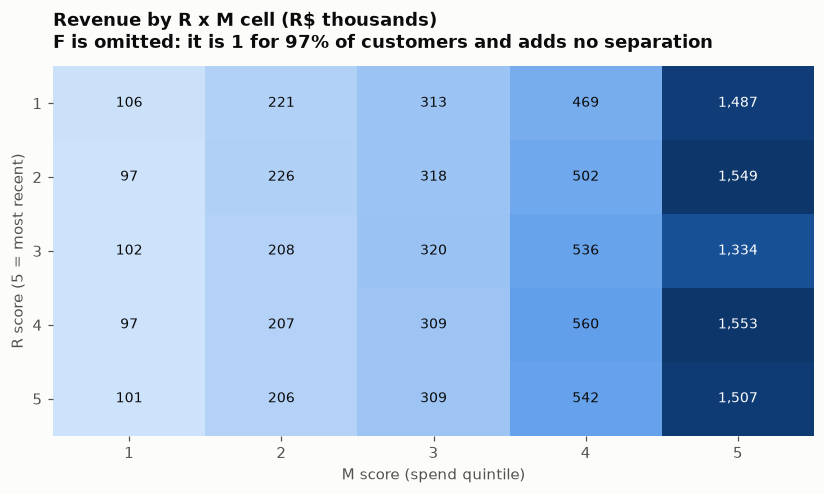

In [7]:
grid = customers.pivot_table(index="r_score", columns="m_score",
                             values="monetary", aggfunc="sum") / 1000

fig, ax = plt.subplots(figsize=(7.6, 4.6))
im = ax.imshow(grid.values, cmap=SEQ_CMAP, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(5)); ax.set_yticklabels(grid.index)
ax.set_xlabel("M score (spend quintile)"); ax.set_ylabel("R score (5 = most recent)")
ax.set_title("Revenue by R x M cell (R$ thousands)\n"
             "F is omitted: it is 1 for 97% of customers and adds no separation")
for i in range(5):
    for j in range(5):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:,.0f}", ha="center", va="center", fontsize=9,
                color="#ffffff" if v > np.nanmax(grid.values) * 0.55 else INK)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
plt.tight_layout(); plt.show()

In [8]:
FEATURES = ["recency", "frequency", "monetary", "aov", "n_categories"]
X = customers[FEATURES].copy()

skew_before = X.skew()
X_log = X.copy()
for col in ["frequency", "monetary", "aov", "n_categories"]:
    X_log[col] = np.log1p(X_log[col])

comparison = pd.DataFrame({"skew_raw": skew_before, "skew_after_log1p": X_log.skew()}).round(2)
comparison["transformed"] = [c != "recency" for c in FEATURES]
display(comparison)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
print(f"feature matrix: {X_scaled.shape}")
print("\nNote: frequency and n_categories stay skewed even after log1p (6.5 and 6.7).")
print("No transform fixes a variable that is a constant for 97% of rows — this is a")
print("property of the business, and it limits what clustering can find.")

,skew_raw,skew_after_log1p,transformed
recency,0.41,0.41,False
frequency,11.12,6.53,True
monetary,9.76,0.28,True
aov,9.94,0.29,True
n_categories,7.59,6.73,True


feature matrix: (93104, 5)

Note: frequency and n_categories stay skewed even after log1p (6.5 and 6.7).
No transform fixes a variable that is a constant for 97% of rows — this is a
property of the business, and it limits what clustering can find.


In [9]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=20000, replace=False)

results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled[sample_idx], km.labels_[sample_idx]),
    })

scores = pd.DataFrame(results).set_index("k")
scores["inertia_drop_pct"] = -scores.inertia.pct_change() * 100
display(scores.round(4))

,inertia,silhouette,inertia_drop_pct
k,,,
2,"337,840.52",0.73,NaN
3,"224,843.96",0.35,33.45
4,"183,447.99",0.34,18.41
5,"149,737.49",0.36,18.38
6,"119,555.79",0.36,20.16
7,"102,713.80",0.35,14.09
8,"86,426.00",0.36,15.86


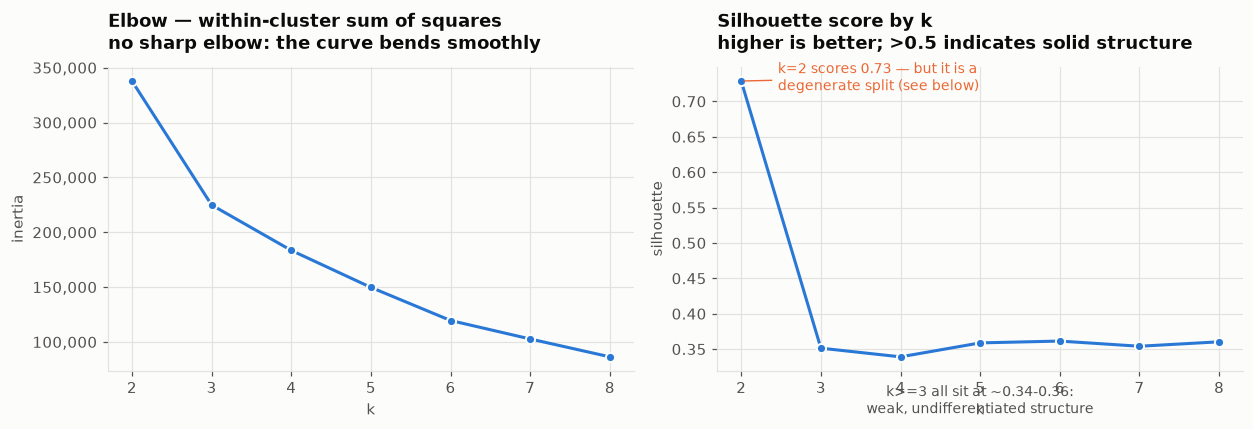

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

ax = axes[0]
ax.plot(scores.index, scores.inertia, color=BLUE, linewidth=2, marker="o",
        markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.3)
ax.set_title("Elbow — within-cluster sum of squares\nno sharp elbow: the curve bends smoothly")
ax.set_xlabel("k"); ax.set_ylabel("inertia")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
despine(ax)

ax = axes[1]
ax.plot(scores.index, scores.silhouette, color=BLUE, linewidth=2, marker="o",
        markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.3)
ax.annotate("k=2 scores 0.73 — but it is a\ndegenerate split (see below)",
            xy=(2, scores.silhouette.iloc[0]), xytext=(24, -6),
            textcoords="offset points", fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=0.9))
ax.annotate("k>=3 all sit at ~0.34-0.36:\nweak, undifferentiated structure",
            xy=(5, scores.silhouette.loc[5]), xytext=(0, -46),
            textcoords="offset points", fontsize=9, color=INK_2, ha="center")
ax.set_title("Silhouette score by k\nhigher is better; >0.5 indicates solid structure")
ax.set_xlabel("k"); ax.set_ylabel("silhouette")
despine(ax)

plt.tight_layout(); plt.show()

In [11]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
check = customers.copy()
check["k2"] = km2.labels_

print("WHAT DOES k=2 SEPARATE?")
display(check.groupby("k2").agg(
    customers=("monetary", "size"), recency=("recency", "mean"),
    frequency=("frequency", "mean"), monetary=("monetary", "mean"),
    n_categories=("n_categories", "mean")).round(2))

print("\ncross-tab of cluster against 'bought in more than one category':")
display(pd.crosstab(check.k2, check.n_categories > 1))
print("\n=> Cluster 1 contains ZERO multi-category customers. k=2 is not finding customer")
print("   segments; it is splitting on a feature that is binary for 97.5% of the base.")
print("   Its high silhouette (0.73) measures that separation, not business structure.")
print("   This is why the silhouette maximum is rejected in favour of an interpretable k.")

WHAT DOES k=2 SEPARATE?


,customers,recency,frequency,monetary,n_categories
k2,,,,,
0,2320,209.17,1.84,248.94,2.04
1,90784,238.98,1.01,138.83,1.00



cross-tab of cluster against 'bought in more than one category':


n_categories,False,True
k2,,
0,60,2260
1,90784,0



=> Cluster 1 contains ZERO multi-category customers. k=2 is not finding customer
   segments; it is splitting on a feature that is binary for 97.5% of the base.
   Its high silhouette (0.73) measures that separation, not business structure.
   This is why the silhouette maximum is rejected in favour of an interpretable k.


In [12]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
customers["cluster"] = kmeans.labels_

profile = customers.groupby("cluster").agg(
    customers=("monetary", "size"), avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"), avg_monetary=("monetary", "mean"),
    avg_aov=("aov", "mean"), avg_categories=("n_categories", "mean"),
    avg_items=("total_items", "mean"), revenue=("monetary", "sum"),
    avg_review=("avg_review", "mean"))
profile["pct_of_customers"] = profile.customers / profile.customers.sum() * 100
profile["pct_of_revenue"] = profile.revenue / profile.revenue.sum() * 100
display(profile.round(2))

,customers,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_categories,avg_items,revenue,avg_review,pct_of_customers,pct_of_revenue
cluster,,,,,,,,,,,
0,31572,152.52,1.01,45.24,45.00,1.00,1.07,"1,428,364.51",4.18,33.91,10.84
1,24445,417.64,1.01,80.68,79.99,1.00,1.11,"1,972,128.31",4.22,26.26,14.96
2,34767,191.88,1.02,264.70,261.18,1.00,1.24,"9,202,994.82",4.10,37.34,69.82
3,2320,209.17,1.84,248.94,147.33,2.04,2.57,"577,539.49",3.88,2.49,4.38


In [13]:
LABELS = {}
for cid, row in profile.iterrows():
    if row.avg_categories > 1.5:
        LABELS[cid] = "Multi-category buyers"
    elif row.avg_monetary >= profile.avg_monetary.quantile(0.7):
        LABELS[cid] = "High-value single buyers"
    elif row.avg_recency >= profile.avg_recency.quantile(0.7):
        LABELS[cid] = "Dormant low-value"
    else:
        LABELS[cid] = "Recent low-value"

customers["cluster_name"] = customers.cluster.map(LABELS)
named = profile.copy()
named.index = [LABELS[i] for i in named.index]
display(named[["customers", "pct_of_customers", "avg_recency", "avg_frequency",
               "avg_monetary", "avg_aov", "avg_categories", "pct_of_revenue"]].round(2))

,customers,pct_of_customers,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_categories,pct_of_revenue
Recent low-value,31572,33.91,152.52,1.01,45.24,45.00,1.00,10.84
Dormant low-value,24445,26.26,417.64,1.01,80.68,79.99,1.00,14.96
High-value single buyers,34767,37.34,191.88,1.02,264.70,261.18,1.00,69.82
Multi-category buyers,2320,2.49,209.17,1.84,248.94,147.33,2.04,4.38


In [14]:
crosstab_pct = pd.crosstab(customers.rfm_segment, customers.cluster_name, normalize="index") * 100
print("ROW % — where each RFM segment lands among the K-Means clusters")
display(crosstab_pct.round(1))

print("RAW COUNTS")
display(pd.crosstab(customers.rfm_segment, customers.cluster_name))

ari = adjusted_rand_score(customers.rfm_segment, customers.cluster)
nmi = normalized_mutual_info_score(customers.rfm_segment, customers.cluster)
print(f"\nAdjusted Rand Index       : {ari:.4f}   (0 = random agreement, 1 = identical)")
print(f"Normalised Mutual Info    : {nmi:.4f}")

ROW % — where each RFM segment lands among the K-Means clusters


cluster_name,Dormant low-value,High-value single buyers,Multi-category buyers,Recent low-value
rfm_segment,,,,
At Risk,34.90,61.00,4.10,0.00
Champions,0.00,0.00,100.00,0.00
Lost,81.50,0.30,0.80,17.40
Loyal,0.00,0.00,100.00,0.00
Needs Attention,4.70,46.80,2.10,46.40
New Customers,0.00,12.60,1.20,86.20
Potential Loyalists,0.00,95.00,4.80,0.20


RAW COUNTS


cluster_name,Dormant low-value,High-value single buyers,Multi-category buyers,Recent low-value
rfm_segment,,,,
At Risk,5000,8745,594,0
Champions,0,0,113,0
Lost,18579,78,183,3956
Loyal,0,0,43,0
Needs Attention,866,8711,397,8640
New Customers,0,2773,254,18953
Potential Loyalists,0,14460,736,23



Adjusted Rand Index       : 0.3560   (0 = random agreement, 1 = identical)
Normalised Mutual Info    : 0.4317


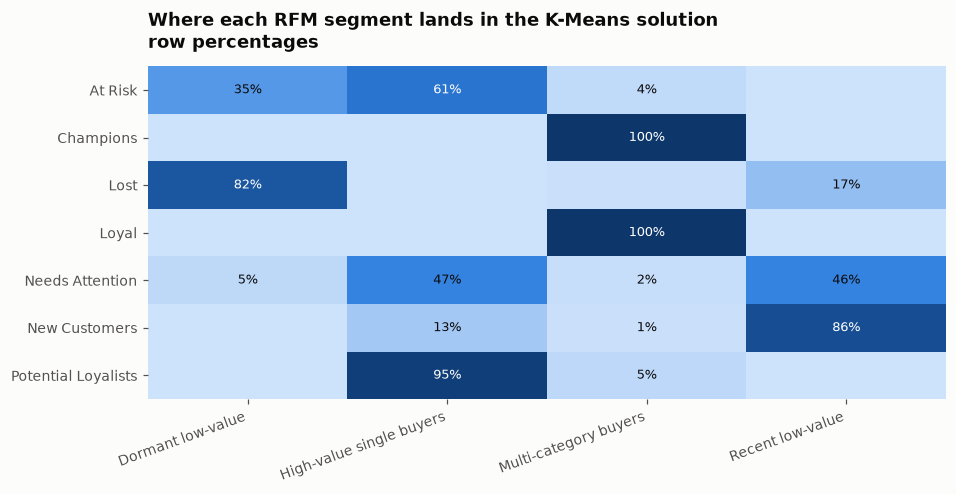

In [15]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
data = crosstab_pct.loc[crosstab_pct.sum(axis=1).sort_values().index]
im = ax.imshow(data.values, cmap=SEQ_CMAP, aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(data.shape[1]))
ax.set_xticklabels(data.columns, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index, fontsize=9)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5,
                    color="#ffffff" if v > 55 else INK)
ax.set_title("Where each RFM segment lands in the K-Means solution\nrow percentages")
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
plt.tight_layout(); plt.show()

In [16]:
out = customers.reset_index()
out.to_parquet(PROC / "customer_segments.parquet", index=False)
print(f"saved customer_segments.parquet: {len(out):,} rows x {out.shape[1]} cols")

summary = out.groupby(["rfm_segment", "cluster_name"]).agg(
    customers=("monetary", "size"), revenue=("monetary", "sum")).reset_index()
print(f"\n{len(summary)} segment x cluster combinations populated")
display(summary.sort_values("revenue", ascending=False).head(8))

saved customer_segments.parquet: 93,104 rows x 30 cols

19 segment x cluster combinations populated


,rfm_segment,cluster_name,customers,revenue
16,Potential Loyalists,High-value single buyers,14460,"3,892,588.89"
1,At Risk,High-value single buyers,8745,"3,090,963.34"
10,Needs Attention,High-value single buyers,8711,"1,929,650.38"
4,Lost,Dormant low-value,18579,"1,145,455.07"
15,New Customers,Recent low-value,18953,"928,161.41"
0,At Risk,Dormant low-value,5000,"754,543.69"
12,Needs Attention,Recent low-value,8640,"384,074.92"
13,New Customers,High-value single buyers,2773,"281,307.75"
